In [4]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import matplotlib.pyplot as plt

load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('POSTGRES_USER', 'postgres')}:{os.getenv('POSTGRES_PASSWORD', 'postgres')}"
    f"@{os.getenv('POSTGRES_HOST', 'localhost')}:{os.getenv('POSTGRES_PORT', '5434')}/{os.getenv('POSTGRES_DB', 'cofair_db')}"
)

In [5]:
# Connect to local Docker Postgres (ensure docker-compose is running)
pricing = pd.read_sql("SELECT * FROM staging.stg_pricing", engine)

In [6]:
# IMPORTANT: The usage table is very big, so please only select a small sample of rows
pd.read_sql("SELECT COUNT(*) FROM staging.stg_usage WHERE session_id IS NOT NULL", engine)

,count
0,15562


In [7]:
pd.read_sql("SELECT COUNT(*) FROM raw.usage", engine)

,count
0,16870


In [38]:
usage = pd.read_sql("SELECT * FROM staging.stg_usage WHERE session_id IS NOT NULL", engine)
usage_copy = usage

## Feel free to play around with the data here!

Data is loaded from your local Postgres DB (`staging.stg_pricing`).

In [9]:
print("Pricing Rows:",len(pricing))
pricing.head(5)

Pricing Rows: 351


,content_sha256,ingested_at,pricing_version,currency,provider,model,sku_type,price_per_1m_tokens_usd,price_per_1k_tokens_usd
0,eeb315ea05288376587aa3ceff42f44505b6c6e555fcfa...,2026-03-20 05:22:34.596942+00:00,2026-03-11T19:39:39Z,USD,anthropic,claude-opus-4.6,base_input_tokens,5.0,0.005
1,eeb315ea05288376587aa3ceff42f44505b6c6e555fcfa...,2026-03-20 05:22:34.596942+00:00,2026-03-11T19:39:39Z,USD,anthropic,claude-opus-4.5,base_input_tokens,5.0,0.005
2,eeb315ea05288376587aa3ceff42f44505b6c6e555fcfa...,2026-03-20 05:22:34.596942+00:00,2026-03-11T19:39:39Z,USD,anthropic,claude-opus-4.1,base_input_tokens,15.0,0.015
3,eeb315ea05288376587aa3ceff42f44505b6c6e555fcfa...,2026-03-20 05:22:34.596942+00:00,2026-03-11T19:39:39Z,USD,anthropic,claude-opus-4,base_input_tokens,15.0,0.015
4,eeb315ea05288376587aa3ceff42f44505b6c6e555fcfa...,2026-03-20 05:22:34.596942+00:00,2026-03-11T19:39:39Z,USD,anthropic,claude-sonnet-4.6,base_input_tokens,3.0,0.003


In [ ]:
# Avg. Pricing by Provider
pricing.groupby("provider").agg({"price_per_1m_tokens_usd":"mean","price_per_1k_tokens_usd":"mean"})

,price_per_1m_tokens_usd,price_per_1k_tokens_usd
provider,,
anthropic,17.262500,0.017263
google,7.448028,0.007448
openai,7.394021,0.007394


In [40]:
usage["total_tokens"] = usage["input_tokens"] + usage["output_tokens"]
usage = usage.drop_duplicates(subset=["total_tokens"], keep="first")

usage['start_time'] = pd.to_datetime(usage['start_time'])
usage['end_time'] = pd.to_datetime(usage['end_time'])

# infer billing cycle start per user (first session date)
usage['cycle_start'] = usage.groupby('dataset_id')['start_time'].transform('min').dt.floor('D')
usage['day_of_cycle'] = (usage['start_time'] - usage['cycle_start']).dt.total_seconds() / 86400

# cumulative tokens per user ordered by day
usage = usage.sort_values(['dataset_id', 'start_time'])
usage['cumulative_tokens'] = usage.groupby('dataset_id')['total_tokens'].cumsum()

usage

/var/folders/zb/yxxlpqwx0vl4c73p4_71xpd00000gn/T/ipykernel_3183/1673001572.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usage['start_time'] = pd.to_datetime(usage['start_time'])
/var/folders/zb/yxxlpqwx0vl4c73p4_71xpd00000gn/T/ipykernel_3183/1673001572.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usage['end_time'] = pd.to_datetime(usage['end_time'])
/var/folders/zb/yxxlpqwx0vl4c73p4_71xpd00000gn/T/ipykernel_3183/1673001572.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of

,dataset_id,session_id,model,git_branch,start_time,end_time,project,messages,input_tokens,output_tokens,total_tokens,cycle_start,day_of_cycle,cumulative_tokens
761,Batman787/dataclaw-Batman787,18975bb9-0add-4c89-8976-8f0fa8c1e3be,claude-opus-4-5-20251101,main,2026-02-01 07:37:10.912,2026-02-01 14:51:04.847,clean-openclaw-openclaw,"[{'role': 'user', 'content': 'You are tasked w...",16423345,508,16423853,2026-02-01,0.317487,16423853
762,Batman787/dataclaw-Batman787,c1e10a0e-cdec-4330-a9a4-917e9fda17dc,claude-opus-4-5-20251101,main,2026-02-01 14:51:56.386,2026-02-01 15:00:43.035,clean-openclaw-openclaw,"[{'role': 'user', 'content': '<ide_selection>T...",959304,121,959425,2026-02-01,0.619403,17383278
760,Batman787/dataclaw-Batman787,586a3989-24ba-4e74-9e94-f72f342ff49b,claude-opus-4-5-20251101,main,2026-02-01 15:08:52.824,2026-02-01 15:10:05.545,clean-glass,"[{'role': 'user', 'content': 'run this applica...",333963,31,333994,2026-02-01,0.631167,17717272
759,Batman787/dataclaw-Batman787,c3e77178-21c1-46f2-a5b4-8fc4336c1742,claude-opus-4-5-20251101,,2026-02-02 05:59:22.582,2026-02-02 06:00:17.849,Vscode-STM,"[{'role': 'user', 'content': '<ide_opened_file...",94570,28,94598,2026-02-01,1.249567,17811870
758,Batman787/dataclaw-Batman787,8938975c-3249-448f-80b2-e6a5ac21dd4c,claude-opus-4-5-20251101,,2026-02-02 06:02:36.718,2026-02-02 06:09:38.616,Vscode-LLm-Memory,"[{'role': 'user', 'content': 'study the code b...",5489693,223,5489916,2026-02-01,1.251814,23301786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5984,zhiyaowang/dataclaw-zhiyaowang,36ebfae3-def6-4c48-a5de-0f058afd0cc8,kimi-k2.5,HEAD,2026-02-26 06:32:32.003,2026-02-26 06:32:56.279,~Downloads,"[{'role': 'user', 'content': 'Last login: Thu ...",35460,484,35944,2026-01-14,43.272593,1144795013
5969,zhiyaowang/dataclaw-zhiyaowang,ses_3674ff703ffeehv6Ke8L0w44a6,minimax-cn-coding-plan/MiniMax-M2.5,None,2026-02-26 06:43:19.420,2026-02-26 06:44:23.819,opencode:Downloads,"[{'role': 'user', 'content': '写一个 aria2c 脚本 下载...",77169,1082,78251,2026-01-14,43.280086,1144873264
5954,zhiyaowang/dataclaw-zhiyaowang,019c99a2-d06b-71d0-b976-406465bb5302,gpt-5.3-codex,main,2026-02-26 11:08:30.340,2026-02-26 12:19:55.769,codex:vesuvius,"[{'role': 'user', 'content': 'Help me export m...",5937833,24886,5962719,2026-01-14,43.464240,1150835983
6013,zhiyaowang/dataclaw-zhiyaowang,ses_36658c33dffesp0bFmk8IirH43,opencode/minimax-m2.5-free,None,2026-02-26 11:13:20.066,2026-02-26 11:29:51.786,opencode:root,"[{'role': 'user', 'content': 'Help me export m...",198234,1547,199781,2026-01-14,43.467593,1151035764


In [ ]:
import sys
!{sys.executable} -m pip install seaborn
!pip install seaborn
import seaborn as sns

<Axes: xlabel='day_of_cycle', ylabel='cumulative_tokens'>

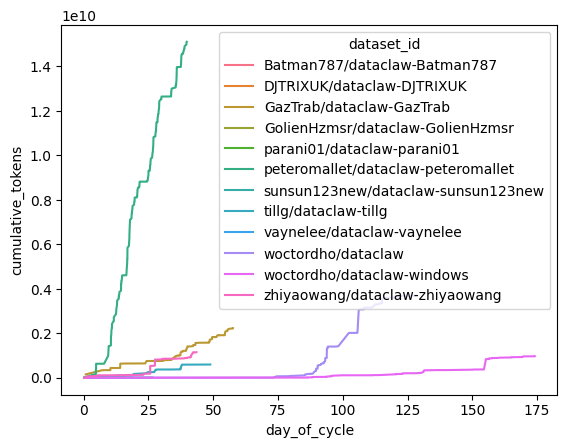

In [41]:
sns.lineplot(usage, x="day_of_cycle", y="cumulative_tokens", hue="dataset_id")

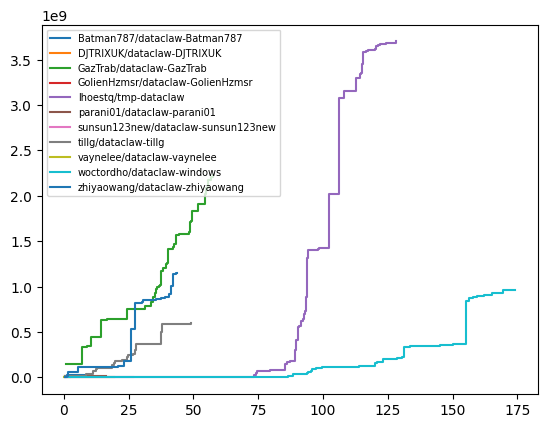

In [49]:
fig, ax = plt.subplots()
for user, user_df in usage.groupby('dataset_id'):
    if user not in ["0010Grent/dataclaw-peteromallet"]:
        ax.step(user_df['day_of_cycle'], user_df['cumulative_tokens'], where='post', label=user)
ax.legend(fontsize=7)
plt.show()

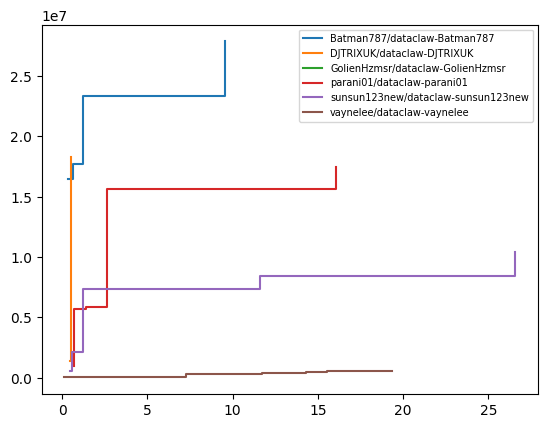

In [48]:
fig, ax = plt.subplots()
for user, user_df in usage.groupby('dataset_id'):
    if user not in ["0010Grent/dataclaw-peteromallet", "lhoestq/tmp-dataclaw", "GazTrab/dataclaw-GazTrab", "woctordho/dataclaw-windows", "zhiyaowang/dataclaw-zhiyaowang","tillg/dataclaw-tillg"]:
        ax.step(user_df['day_of_cycle'], user_df['cumulative_tokens'], where='post', label=user)
ax.legend(fontsize=7)
plt.show()

<Axes: xlabel='day_of_cycle', ylabel='cumulative_tokens'>

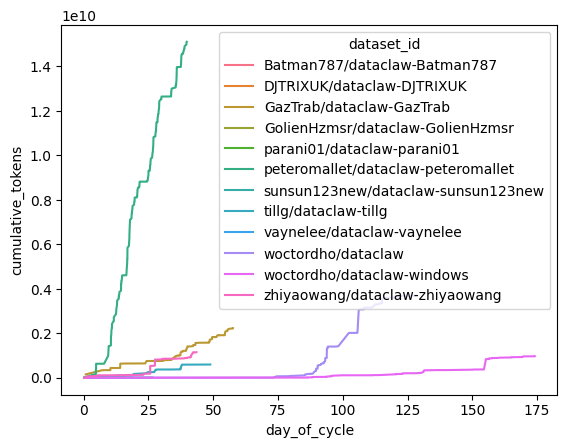

In [32]:
sns.lineplot(usage, x="day_of_cycle", y="cumulative_tokens", hue="dataset_id")

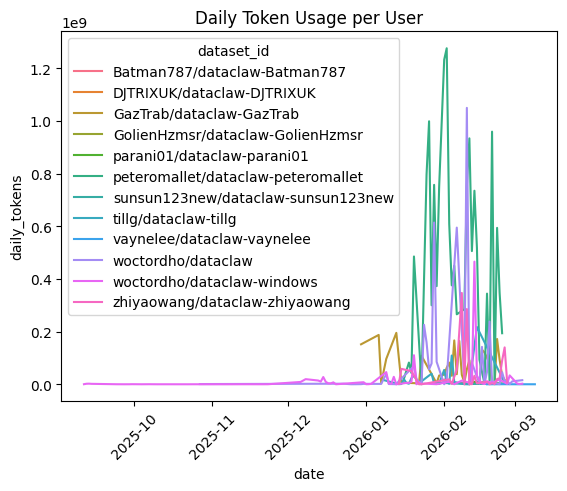

In [ ]:
# Aggregate total tokens per user per day
daily_usage = usage.groupby(["dataset_id", usage["start_time"].dt.floor("D")])["total_tokens"].sum().reset_index()
daily_usage.columns = ["dataset_id", "date", "daily_tokens"]

sns.lineplot(daily_usage, x="date", y="daily_tokens", hue="dataset_id")
plt.xticks(rotation=45)
plt.title("Daily Token Usage per User")
plt.show()

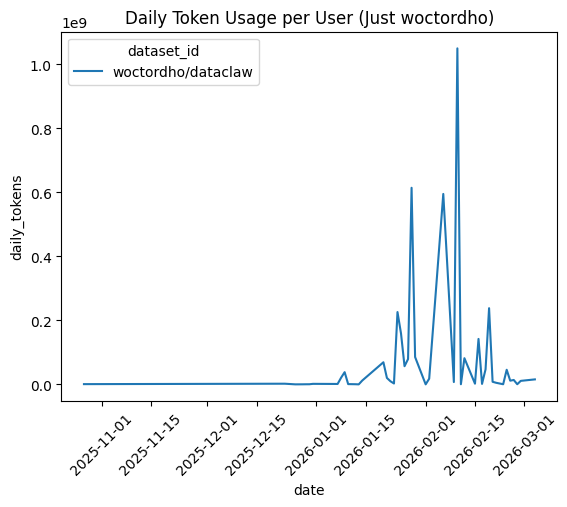

In [83]:
sns.lineplot(daily_usage[daily_usage["dataset_id"]=="woctordho/dataclaw"], x="date", y="daily_tokens", hue="dataset_id")
plt.xticks(rotation=45)
plt.title("Daily Token Usage per User (Just woctordho)")
plt.show()

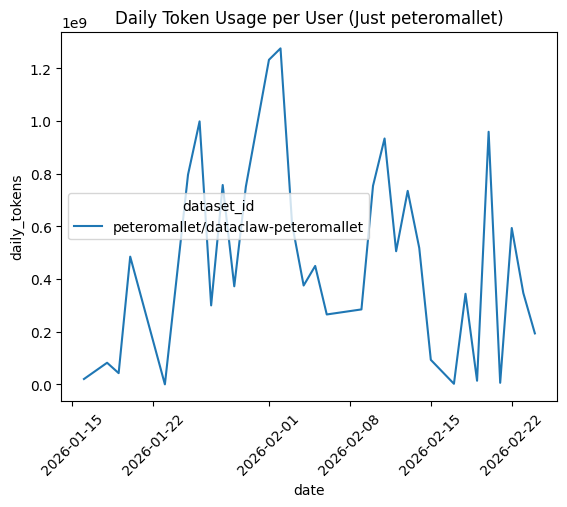

In [71]:
sns.lineplot(daily_usage[daily_usage["dataset_id"].str.contains("peteromallet/")], x="date", y="daily_tokens", hue="dataset_id")
plt.xticks(rotation=45)
plt.title("Daily Token Usage per User (Just peteromallet)")
plt.show()

In [88]:
user_data = daily_usage[daily_usage["dataset_id"] == "woctordho/dataclaw"].sort_values("date")
user_data = user_data.set_index("date")
user_data.index = pd.DatetimeIndex(user_data.index).to_period("D")

train = user_data["daily_tokens"].iloc[:-7]
val = user_data["daily_tokens"].iloc[-7:]

In [91]:
# --- Naive Model ---
# predicts the previous day's usage
naive = [train.iloc[-1]] * 7

# --- Exponential Smoothing Model ---
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
exp_model = SimpleExpSmoothing(train).fit()
exp_forecast = exp_model.forecast(7)

# --- ARIMA ---
from statsmodels.tsa.arima.model import ARIMA
arima_model = ARIMA(train, order=(2, 0, 2)).fit()
arima_forecast = arima_model.forecast(7)

# --- XG Boost ---
from xgboost import XGBRegressor
user_data_df = user_data.reset_index()
for lag in [1, 2, 3, 7]:
    user_data_df[f"lag_{lag}"] = user_data_df["daily_tokens"].shift(lag)

user_data_df = user_data_df.dropna()
X = user_data_df[[c for c in user_data_df.columns if "lag" in c]]
y = user_data_df["daily_tokens"]

X_train, X_test = X.iloc[:-7], X.iloc[-7:]
y_train, y_test = y.iloc[:-7], y.iloc[-7:]

model = XGBRegressor().fit(X_train, y_train)
xg_preds = model.predict(X_test)

# --- Prophet ---
from prophet import Prophet
pdf = train.reset_index()
pdf.columns = ["ds", "y"]
pdf["ds"] = pdf["ds"].dt.to_timestamp()

m = Prophet(daily_seasonality=True).fit(pdf)
prophet_forecast = m.predict(m.make_future_dataframe(7))["yhat"].iloc[-7:].values

/Users/andrewtaylor/Desktop/the-colonial/venv/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
Importing plotly failed. Interactive plots will not work.
20:29:49 - cmdstanpy - INFO - Chain [1] start processing
20:29:50 - cmdstanpy - INFO - Chain [1] done processing


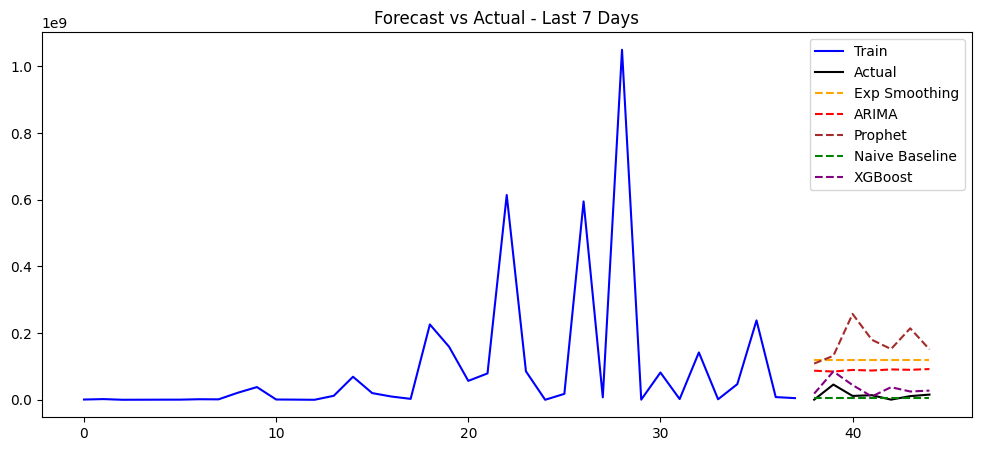

In [92]:
plt.figure(figsize=(12, 5))
plt.plot(train.values, label="Train", color="blue")
plt.plot(range(len(train), len(train)+7), val.values, label="Actual", color="black")
plt.plot(range(len(train), len(train)+7), exp_forecast.values, label="Exp Smoothing", color="orange", linestyle="--")
plt.plot(range(len(train), len(train)+7), arima_forecast.values, label="ARIMA", color="red", linestyle="--")
plt.plot(range(len(train), len(train)+7), prophet_forecast, label="Prophet", color="brown", linestyle="--")
plt.plot(range(len(train), len(train)+7), naive, label="Naive Baseline", color="green", linestyle="--")
plt.plot(range(len(train), len(train)+7), xg_preds, label="XGBoost", color="purple", linestyle="--")
plt.legend()
plt.title("Forecast vs Actual - Last 7 Days")
plt.show()

In [93]:
from sklearn.metrics import mean_absolute_error

print(f"Exp Smoothing MAE: {mean_absolute_error(val, exp_forecast):,.0f}")
print(f"ARIMA MAE: {mean_absolute_error(val, arima_forecast):,.0f}")
print(f"XGBoost MAE: {mean_absolute_error(y_test, xg_preds):,.0f}")
print(f"Prophet MAE: {mean_absolute_error(val, prophet_forecast):,.0f}")
print(f"Naive baseline MAE:{mean_absolute_error(val, naive):,.0f}")


Exp Smoothing MAE: 106,188,375
ARIMA MAE: 74,855,483
XGBoost MAE: 22,421,748
Prophet MAE: 156,806,173
Naive baseline MAE:11,672,141
